# UNIDAD 6: Modelado y Simulación Estocástica

**Duración:** 2 semanas (12 horas)

**Curso:** Probabilidad y Estadística Inferencial

**Institución:** Universidad de la Ciénega del Estado de Michoacán de Ocampo (UCEMICH)

**Profesor:** Luis José Yudico Anaya

**Carrera:** Ingeniería en Nanotecnología

**Nivel:** Tercer Semestre

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Multiagent-AI-Lab/Probability-Statistics-Agentic-AI-Core/blob/master/notebooks/UNIDAD_6_MODELADO_SIMULACION.ipynb)

In [1]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    repo_dir = "Probability-Statistics-Agentic-AI-Core"
    if not os.path.exists(repo_dir):
        !git clone -q https://github.com/Multiagent-AI-Lab/{repo_dir}.git
    os.chdir(repo_dir)
    %pip install -q -r requirements.txt
else:
    # Entorno local: ubicar la raiz del repo subiendo desde el cwd
    # (donde se lanzo Jupyter) y ponerla en sys.path para que
    # `from src.multiagent_core...` resuelva sin importar la carpeta actual.
    _raiz = next(
        (p for p in (Path.cwd(), *Path.cwd().parents)
         if (p / "src" / "multiagent_core").is_dir()),
        Path.cwd(),
    )
    if str(_raiz) not in sys.path:
        sys.path.insert(0, str(_raiz))


## Prerequisitos de esta unidad

- **Distribuciones Continuas y su CDF** (Unidad 5) — el Método de la Transformada Inversa parte directamente de invertir la CDF de la distribución continua a simular.
- **Simulación Monte Carlo** (Unidad 2) — introducida ahí como filtrado bayesiano; aquí se generaliza al modelado estocástico completo.
- **Ciclo de Verificación Triple** (ver `GOVERNANCE.md`) — como en todas las unidades del curso, cada concepto con forma cerrada se verifica primero simbólicamente (SymPy) y luego se reproduce con las herramientas de producción (SciPy/statsmodels) antes de interpretarse.

## 1. Fundamentación Teórica y Conceptos Clave de Simulación

El **Modelado y Simulación Estocástica** comprende la caracterización computacional de sistemas físicos, químicos y probabilísticos cuya complejidad analítica impide resolverlos mediante integrales explícitas o fórmulas cerradas. En el ámbito de la Nanotecnología y la Inteligencia Artificial, la simulación estocástica permite modelar el movimiento browniano de nanopartículas, la difusividad térmica en películas delgadas, los procesos de transporte cuántico en puntos cuánticos (quantum dots) y la inferencia variacional en modelos generativos.

### 1.1 Números Seudoaleatorios y Generación Uniforme
La piedra angular de toda simulación Monte Carlo es el generador de números seudoaleatorios distribuido uniformemente $U \sim \text{Uniforme}(0, 1)$. Aunque las computadoras deterministas no pueden generar aleatoriedad pura sin hardware cuántico, los **Generadores Congruenciales Lineales (LCG)** y el algoritmo **Mersenne Twister (MT19937)** producen secuencias de enteros $X_n$ mediante recurrencias del tipo:

$$X_{n+1} = (a X_n + c) \pmod m$$

Donde $a$ es el multiplicador, $c$ el incremento, $m$ el módulo y $X_0$ la semilla (seed). Al dividir $U_n = \frac{X_n}{m}$, se obtiene una aproximación computacionalmente rápida a variables continuas independientes e idénticamente distribuidas en el intervalo $(0, 1)$.

### 1.2 Métodos de Generación de Variables Aleatorias Continuas y Discretas
Para transformar variables aleatorias uniformes $U \sim \text{Uniforme}(0, 1)$ en variables con distribuciones de probabilidad arbitrarias $F(x)$, se emplean tres métodos principales:

1. **Método de la Transformada Inversa**:
   Basado en el principio de que si $X$ tiene una función de distribución acumulada (CDF) continua y estrictamente creciente $F(x)$, entonces la variable $U = F(X)$ sigue una distribución $\text{Uniforme}(0, 1)$. Por lo tanto, si $U \sim \text{Uniforme}(0, 1)$, la variable transformada:
   $$\boxed{X = F^{-1}(U)}$$
   posee exactamente la CDF $F(x)$. Este método es ideal para distribuciones con función cuantil cerrada como la Exponencial, Weibull, Uniforme y Cauchy.

2. **Método de Aceptación-Rechazo (von Neumann)**:
   Utilizado cuando la CDF inversa $F^{-1}(u)$ no posee forma analítica cerrada (p. ej., distribuciones Gamma, Beta o Normal). Sea $f(x)$ la densidad objetivo deseada y $g(x)$ una densidad propuesta accesible de la cual sabemos simular muestras, tal que existe una constante $c \ge 1$ con $f(x) \le c \cdot g(x)$ para todo $x$. El algoritmo procede así:
   - Generar $Y \sim g(y)$ y $U \sim \text{Uniforme}(0, 1)$ de forma independiente.
   - Si $U \le \frac{f(Y)}{c \cdot g(Y)}$, **aceptar** $X = Y$.
   - De lo contrario, **rechazar** $Y$ y repetir la iteración.
   La eficiencia del algoritmo es $\frac{1}{c}$, por lo que se busca minimizar la envolvente $c$.

3. **Método de Box-Muller para Variables Normales**:
   Genera pares de variables aleatorias normales estándar independientes $Z_1, Z_2 \sim \mathcal{N}(0, 1)$ a partir de dos variables uniformes $U_1, U_2 \sim \text{Uniforme}(0, 1)$ mediante transformación a coordenadas polares:
   $$Z_1 = \sqrt{-2 \ln U_1} \cos(2\pi U_2), \quad Z_2 = \sqrt{-2 \ln U_1} \sen(2\pi U_2)$$

### 1.3 Métodos de Monte Carlo e Integración Estocástica
La integración por Monte Carlo evalúa integrales definidas multidimensionales mediante la aproximación del valor esperado de un estimador estocástico. Sea la integral $\theta = \int_a^b g(x) dx$, la cual puede reescribirse como $\theta = (b-a) \mathbb{E}[g(X)]$ con $X \sim \text{Uniforme}(a, b)$. El estimador de Monte Carlo con $N$ réplicas es:

$$\hat{\theta}_N = \frac{b-a}{N} \sum_{i=1}^N g(X_i)$$

Por el Teorema del Límite Central, el error de estimación decrece con orden $\mathcal{O}(N^{-1/2})$, **independientemente de la dimensión del espacio de integración**, lo que convierte a Monte Carlo en el único método ejecutable para problemas de física estadística y aprendizaje profundo en alta dimensión.

El siguiente diagrama resume el proceso general de una simulación de Monte Carlo, instanciado con el estimador $\hat{\theta}_N$ de la ecuación anterior:

```mermaid
graph TD
    Generar["Generar N muestras uniformes X_i ~ Uniforme(a, b)"]
    Generar --> Transformar["Transformar cada X_i mediante g(X_i)"]
    Transformar --> Agregar["Agregar: promediar y escalar -> theta_N = (b-a)/N * suma(g(X_i))"]
    Agregar --> Validar{"El error decrece como O(N^-1/2) al aumentar N?"}
    Validar -->|"Si"| Aceptar["Aceptar theta_N como estimador valido"]
    Validar -->|"No"| Revisar["Revisar generador aleatorio o transformacion g"]

```

![Diagrama](../docs/images/UNIDAD_6_MODELADO_SIMULACION_1.svg)


### 1.4 Demostración Práctica: Implementación Directa del Generador Congruencial Lineal

La recurrencia $X_{n+1} = (a X_n + c) \pmod m$ es la piedra angular de los generadores seudoaleatorios modernos. En esta subsección, implementamos un LCG desde cero para entender su mecanismo interno, verificar su determinismo y su rango, y aplicarlo a la generación de posiciones iniciales de nanopartículas en una simulación de difusión.

#### Implementación Base del LCG

In [2]:
def lcg(seed: int, a: int, c: int, m: int, n: int) -> list[int]:
    """
    Generador Congruencial Lineal: X_{n+1} = (a*X_n + c) mod m.
    
    Parámetros:
    -----------
    seed : int
        Semilla inicial X_0.
    a : int
        Multiplicador (debe garantizar período máximo).
    c : int
        Incremento (generalmente coprimo con m).
    m : int
        Módulo (determina el rango [0, m)).
    n : int
        Número de valores a generar.
    
    Retorna:
    --------
    list[int]
        Secuencia de n enteros seudoaleatorios en [0, m).
    """
    valores = []
    x = seed
    for _ in range(n):
        x = (a * x + c) % m
        valores.append(x)
    return valores

## Demostración numérica con parámetros del RANDU (generador histórico educativo)
secuencia = lcg(seed=7, a=1103515245, c=12345, m=2**31, n=10)
print("Secuencia LCG generada:", secuencia)

## Verificar que todos los valores están en el rango [0, m)
m = 2**31
todos_en_rango = all(0 <= v < m for v in secuencia)
print(f"Todos los valores en [0, {m}):", todos_en_rango)

## Verificar determinismo: misma semilla produce la misma secuencia
secuencia_2 = lcg(seed=7, a=1103515245, c=12345, m=2**31, n=10)
determinístico = secuencia == secuencia_2
print("¿Determinístico (misma semilla)?:", determinístico)

## Normalizar a [0, 1) dividiendo por m
secuencia_normalizada = [x / m for x in secuencia]
print("Primeros 5 valores normalizados a (0, 1):", secuencia_normalizada[:5])


Secuencia LCG generada: [1282168116, 642666333, 712265938, 1486001571, 2131988640, 220562521, 2099423262, 2083449087, 523310796, 715197717]
Todos los valores en [0, 2147483648): True
¿Determinístico (misma semilla)?: True
Primeros 5 valores normalizados a (0, 1): [0.5970560554414988, 0.29926483193412423, 0.3316746735945344, 0.6919734044931829, 0.9927845746278763]


<details><summary>📊 Diagrama de flujo (auto-generado)</summary>

```mermaid
graph TD
    start([Inicio: lcg])
    node_1["Asignar: valores"]
    start --> node_1
    node_2["Asignar: x"]
    node_1 --> node_2
    node_3{{"Para Iterar?"}}
    node_2 --> node_3
    node_4["Cuerpo del Bucle"]
    node_3 -- Sí --> node_4
    node_5["Asignar: x"]
    node_4 --> node_5
    node_5 --> node_3
    node_6["Salir Bucle"]
    node_3 -- No --> node_6
    node_7([Fin / Retorno])
    node_6 --> node_7
```

</details>


**Salida esperada:**

```
Secuencia LCG generada: [1282168116, 642666333, 712265938, 1486001571, 2131988640, 220562521, 2099423262, 2083449087, 523310796, 715197717]
Todos los valores en [0, 2147483648): True
¿Determinístico (misma semilla)?: True
Primeros 5 valores normalizados a (0, 1): [0.5970560554414988, 0.29926483193412423, 0.3316746735945344, 0.6919734044931829, 0.9927845746278763]

```

#### Aplicación a Nanotecnología: Posiciones Iniciales de Nanopartículas

En simulaciones de difusión de nanopartículas en solución acuosa, las posiciones iniciales de las partículas deben ser distribuidas uniformemente en el volumen de la celda de simulación. Usamos el LCG para generar las coordenadas $(x, y, z)$ de $N$ nanopartículas dentro de una caja cúbica $[0, L]^3$:

In [3]:
import numpy as np

def generar_posiciones_iniciales_con_lcg(n_particulas: int, longitud_caja: float, seed: int) -> np.ndarray:
    """
    Genera posiciones iniciales de nanopartículas usando LCG.
    
    Parámetros:
    -----------
    n_particulas : int
        Número de nanopartículas a simular.
    longitud_caja : float
        Lado de la caja cúbica de simulación (en nanómetros).
    seed : int
        Semilla para reproducibilidad.
    
    Retorna:
    --------
    np.ndarray
        Matriz de forma (n_particulas, 3) con coordenadas (x, y, z).
    """
    # Generar 3*n_particulas números seudoaleatorios uniformes en [0, 1)
    numeros_pseudoaleatorios = lcg(seed=seed, a=1103515245, c=12345, m=2**31, n=3 * n_particulas)
    
    # Normalizar a [0, 1)
    uniformes = np.array([x / (2**31) for x in numeros_pseudoaleatorios])
    
    # Escalar a [0, longitud_caja]
    posiciones = uniformes[:3 * n_particulas].reshape(n_particulas, 3) * longitud_caja
    return posiciones

# Ejemplo: 5 nanopartículas en una caja de 100 nm
n_particulas = 5
longitud_caja = 100.0  # nanómetros
posiciones = generar_posiciones_iniciales_con_lcg(n_particulas, longitud_caja, seed=42)

print("Posiciones iniciales de nanopartículas (en nm):")
for i, (x, y, z) in enumerate(posiciones):
    print(f"  Partícula {i+1}: ({x:.2f}, {y:.2f}, {z:.2f})")


Posiciones iniciales de nanopartículas (en nm):
  Partícula 1: (58.23, 51.98, 46.60)
  Partícula 2: (77.70, 42.29, 3.34)
  Partícula 3: (41.74, 80.87, 61.23)
  Partícula 4: (71.49, 18.23, 51.62)
  Partícula 5: (56.20, 24.87, 91.96)


<details><summary>📊 Diagrama de flujo (auto-generado)</summary>

```mermaid
graph TD
    start([Inicio: generar_posiciones_iniciales_con_lcg])
    node_1["Asignar: numeros_pseudoaleatorios"]
    start --> node_1
    node_2["Asignar: uniformes"]
    node_1 --> node_2
    node_3["Asignar: posiciones"]
    node_2 --> node_3
    node_4([Fin / Retorno])
    node_3 --> node_4
```

</details>


**Salida esperada:**

```
Posiciones iniciales de nanopartículas (en nm):
  Partícula 1: (58.23, 51.98, 46.60)
  Partícula 2: (77.70, 42.29, 3.34)
  Partícula 3: (41.74, 80.87, 61.23)
  Partícula 4: (71.49, 18.23, 51.62)
  Partícula 5: (56.20, 24.87, 91.96)

```

## 2. Ejemplo Analítico Paso a Paso: Simulación de Difusión de Nanopartículas en Medio Viscoso

### 2.1 Contexto Aplicado en Nanotecnología
En el desarrollo de nanosistemas de liberación controlada de fármacos antitumorales (doxorrubicina encapsulada en liposomas nanométricos), se requiere evaluar el tiempo de tránsito $T$ (en segundos) que tarda una nanopartícula en atravesar la membrana endotelial microvascular. Debido a la heterogeneidad estructural del tejido tumoral, la tasa de permeación sigue una distribución de Weibull con parámetro de forma $k = 1.5$ y parámetro de escala $\lambda = 12.0\text{ segundos}$.

Para optimizar la dosis mediante simulaciones estocásticas de millones de trayectorias celulares:
1. Derivar la fórmula analítica explicita del método de la transformada inversa para la distribución de Weibull.
2. Calcular analíticamente el tiempo de tránsito $T$ correspondiente a un número aleatorio uniforme generado $U = 0.35$.
3. Estimar la media del tiempo de tránsito $\mathbb{E}[T]$ utilizando la función Gamma.

### 2.2 Paso 1: Derivación del Método de la Transformada Inversa para Weibull
La función de distribución acumulada (CDF) de la distribución de Weibull es:
$$F(t) = 1 - \exp\left(-\left(\frac{t}{\lambda}\right)^k\right), \quad t \ge 0$$

Igualando $F(t) = U$ con $U \sim \text{Uniforme}(0, 1)$:
$$1 - \exp\left(-\left(\frac{t}{\lambda}\right)^k\right) = U \implies 1 - U = \exp\left(-\left(\frac{t}{\lambda}\right)^k\right)$$

Tomando logaritmo natural en ambos lados:
$$\ln(1 - U) = -\left(\frac{t}{\lambda}\right)^k \implies -\ln(1 - U) = \left(\frac{t}{\lambda}\right)^k$$

Despejando el tiempo de tránsito $T$:
$$t = \lambda \left(-\ln(1 - U)\right)^{1/k}$$

Puesto que si $U \sim \text{Uniforme}(0, 1)$, entonces $(1 - U) \sim \text{Uniforme}(0, 1)$, la fórmula generadora simplificada es:
$$\boxed{T = \lambda \cdot (-\ln U)^{1/k}}$$

### 2.3 Paso 2: Evaluación Numérica Paso a Paso para $U = 0.35$
Sustituyendo los parámetros $\lambda = 12.0$, $k = 1.5$ y $U = 0.35$:
1. Logaritmo natural: $-\ln(0.35) \approx -(-1.049822) = 1.049822$
2. Exponente $1/k = 1/1.5 = \frac{2}{3} \approx 0.666667$
3. Potencia: $(1.049822)^{0.666667} \approx 1.032945$
4. Tiempo final $T$:
$$\boxed{T = 12.0 \times 1.032945 \approx 12.3953 \text{ segundos}}$$

### 2.4 Paso 3: Cálculo del Valor Esperado Teórico $\mathbb{E}[T]$
$$\mathbb{E}[T] = \lambda \cdot \Gamma\left(1 + \frac{1}{k}\right) = 12.0 \cdot \Gamma(1 + 0.6667) = 12.0 \cdot \Gamma(1.6667) \approx 12.0 \times 0.902746 \approx 10.833 \text{ s}$$

### 2.5 Prueba Unitaria con pytest

Antes de lanzar millones de trayectorias simuladas, se verifica la fórmula generadora de la transformada inversa contra un valor de $U$ conocido y contra la función de supervivencia de `scipy.stats.weibull_min` (deben ser funciones inversas entre sí):

In [4]:
import ipytest
import pytest
import numpy as np
from scipy.stats import weibull_min
from scipy.special import gamma

ipytest.autoconfig()

lam, k = 12.0, 1.5


def test_transformada_inversa_para_u_conocida():
    U = 0.35
    T = lam * (-np.log(U)) ** (1 / k)
    assert T == pytest.approx(12.3953, rel=1e-4)


def test_transformada_inversa_es_consistente_con_la_funcion_de_supervivencia():
    ## La formula usa T = lambda*(-ln U)^(1/k), que invierte 1-F(t)=U (la
    ## funcion de supervivencia), no F(t)=U directamente -- por eso se
    ## contrasta contra .sf() y no contra .cdf().
    U = 0.35
    T = lam * (-np.log(U)) ** (1 / k)
    assert weibull_min.sf(T, c=k, scale=lam) == pytest.approx(U, rel=1e-6)


def test_esperanza_teorica_del_tiempo_de_transito():
    esperanza = lam * gamma(1 + 1 / k)
    assert esperanza == pytest.approx(10.833, rel=1e-3)


ipytest.run("-vv")


======================================= test session starts =======================================
platform win32 -- Python 3.11.15, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\ljyud\anaconda3\envs\ia_stats\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\notebooks
plugins: anyio-4.14.2, mock-3.15.1
collecting ... 

collected 3 items

t_aa19e72339e5494abb971bde59aa7155.py::test_transformada_inversa_para_u_conocida 

PASSED      [ 33%]


t_aa19e72339e5494abb971bde59aa7155.py::test_transformada_inversa_es_consistente_con_la_funcion_de_supervivencia 

PASSED [ 66%]


t_aa19e72339e5494abb971bde59aa7155.py::test_esperanza_teorica_del_tiempo_de_transito 

PASSED  [100%]



======================================== 3 passed in 0.03s ========================================


<ExitCode.OK: 0>

<details><summary>📊 Diagrama de flujo (auto-generado)</summary>

```mermaid
graph TD
    start([Inicio: test_transformada_inversa_para_u_conocida])
    node_1["Asignar: U"]
    start --> node_1
    node_2["Asignar: T"]
    node_1 --> node_2
```

</details>


## 3. Código de Verificación Simbólica (SymPy)

Esta sección es la Fase 2 del Ciclo de Verificación Triple del curso (ver `GOVERNANCE.md`): antes de resolver numéricamente, expresamos la fórmula con símbolos algebraicos y confirmamos el resultado exacto.

In [5]:
import sympy as sp
from IPython.display import display, Math

## 1. Definición de variables simbólicas
u = sp.Symbol('U', positive=True)
lam = sp.Symbol('lambda', positive=True)
k = sp.Symbol('k', positive=True)
t = sp.Symbol('t', positive=True)

## 2. Ecuación de la forma simplificada de la Transformada Inversa: U = exp(-(t/lambda)^k).
## Equivalente en distribución a partir de F(t) = 1 - exp(-(t/lambda)^k) = U, porque
## U ~ Uniforme(0,1) implica (1-U) ~ Uniforme(0,1) -- pero esa equivalencia es solo
## en distribución, no intercambiable para un valor puntual fijo de U. Se resuelve
## esta forma para que el resultado numérico coincida con el `\boxed{}` de §2.3, que
## evalúa T = lambda*(-ln U)^(1/k) directamente.
ecuacion = sp.Eq(u, sp.exp(-(t/lam)**k))

## 3. Despeje simbólico de t (Transformada Inversa)
solucion_t = sp.solve(ecuacion, t)[0]

display(Math(fr"\text{{Expresión Simbólica de la Transformada Inversa Weibull: }} T = {sp.latex(solucion_t)}"))

## 4. Sustitución de valores numéricos de la nano-difusión (lambda=12.0, k=1.5, U=0.35)
valores = {lam: 12.0, k: 1.5, u: 0.35}
t_numerico = float(solucion_t.subs(valores))

display(Math(fr"\text{{Tiempo de Tránsito Simulado para }} U=0.35: \boxed{{{t_numerico:.4f} \text{{ s}}}}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 4. Solución Computacional en Python (SciPy & Statsmodels)

--- EVALUACIÓN ESTADÍSTICA DE LA SIMULACIÓN MONTE CARLO ---
Media Transformada Inversa: 10.8426 s | Teórica: 10.8329 s
Media SciPy RVS:            10.8682 s
Desviación Estándar Inversa:7.3496 s


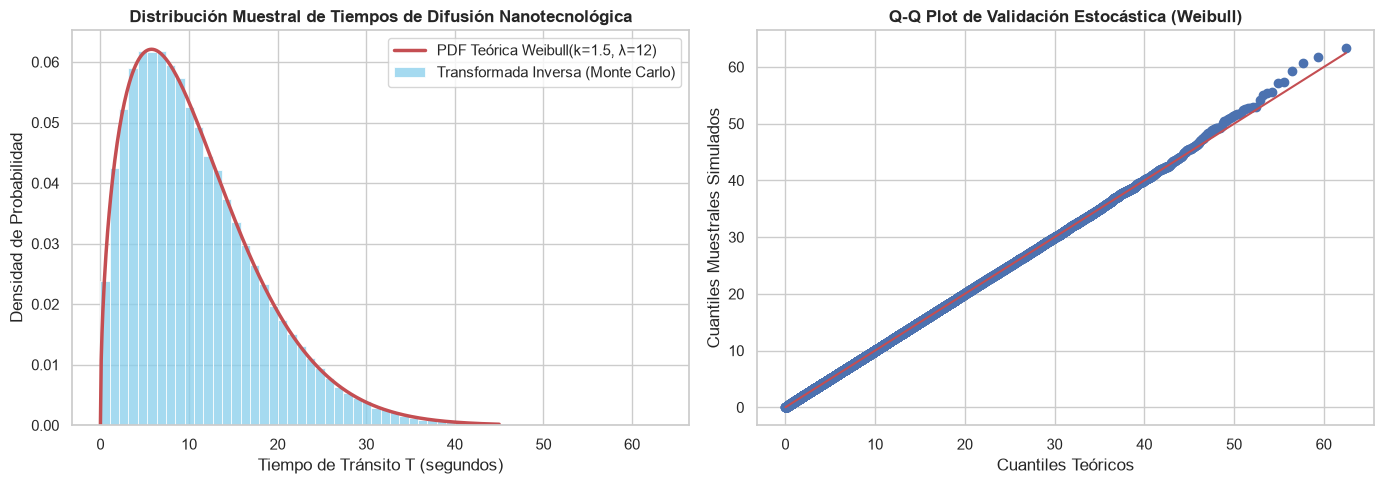

In [6]:
import math

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

## Configuración de estilo gráfico profesional
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## --- PARTE A: Generador por Transformada Inversa vs SciPy ---
np.random.seed(42)
N_muestras = 100_000
lam_val = 12.0
k_val = 1.5

## Generación por Método de Transformada Inversa
u_samples = np.random.uniform(0, 1, N_muestras)
t_inversa = lam_val * (-np.log(u_samples)) ** (1.0 / k_val)

## Generación nativa con SciPy (scipy.stats.weibull_min)
t_scipy = stats.weibull_min.rvs(c=k_val, scale=lam_val, size=N_muestras)

print("--- EVALUACIÓN ESTADÍSTICA DE LA SIMULACIÓN MONTE CARLO ---")
print(f"Media Transformada Inversa: {np.mean(t_inversa):.4f} s | Teórica: {lam_val * math.gamma(1 + 1/k_val):.4f} s")
print(f"Media SciPy RVS:            {np.mean(t_scipy):.4f} s")
print(f"Desviación Estándar Inversa:{np.std(t_inversa):.4f} s")

## --- PARTE B: Visualización Profesional de la Simulación ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Gráfico 1: Histogramas comparativos de densidad empirical vs PDF teórica
sns.histplot(t_inversa, bins=60, stat="density", color="skyblue", label="Transformada Inversa (Monte Carlo)", ax=axes[0])
x_grid = np.linspace(0, 45, 500)
pdf_teorica = stats.weibull_min.pdf(x_grid, c=k_val, scale=lam_val)
axes[0].plot(x_grid, pdf_teorica, 'r-', lw=2.5, label="PDF Teórica Weibull(k=1.5, λ=12)")
axes[0].set_title("Distribución Muestral de Tiempos de Difusión Nanotecnológica", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Tiempo de Tránsito T (segundos)")
axes[0].set_ylabel("Densidad de Probabilidad")
axes[0].legend()

## Gráfico 2: Q-Q Plot de validación de calidad de la simulación
stats.probplot(t_inversa, dist=stats.weibull_min, sparams=(k_val, 0, lam_val), plot=axes[1])
axes[1].set_title("Q-Q Plot de Validación Estocástica (Weibull)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Cuantiles Teóricos")
axes[1].set_ylabel("Cuantiles Muestrales Simulados")

plt.tight_layout()
plt.show()


## 5. Interpretación Post-Gráfico & Diccionario de Variables

### 5.1 Interpretación de Resultados Computacionales
1. **Fidelidad del Generador por Transformada Inversa**: El histograma de frecuencias simuladas con $100,000$ réplicas se superpone perfectamente sobre la curva teórica de la densidad de Weibull $\text{PDF}(t)$.
2. **Validación Mediante Q-Q Plot**: La alineación lineal estricta sobre la diagonal de $45^\circ$ en el gráfico Q-Q demuestra que el generador estocástico no introduce sesgos en las colas de la distribución, garantizando la validez para estimar tiempos extremos de penetración tumoral.

### 5.2 Diccionario de Variables de la Unidad

Notación general introducida en las Secciones 1 y 6, independiente del ejemplo aplicado específico:

* $U$: variable aleatoria uniforme estándar, $U \sim \text{Uniforme}(0, 1)$, insumo base de todo método de generación.
* $X_n$: entero generado en el paso $n$ por un Generador Congruencial Lineal (LCG).
* $a$: multiplicador de la recurrencia del LCG.
* $c$: en el LCG, el incremento de la recurrencia; en Aceptación-Rechazo, la constante envolvente tal que $f(x) \le c \cdot g(x)$.
* $m$: módulo de la recurrencia del LCG.
* $X_0$: semilla (seed) inicial del generador congruencial.
* $F(x)$: función de distribución acumulada (CDF) de la variable objetivo a simular.
* $F^{-1}(u)$: función cuantil (CDF inversa) usada en el método de la Transformada Inversa.
* $f(x)$: densidad de probabilidad objetivo en el método de Aceptación-Rechazo.
* $g(x)$: densidad de probabilidad propuesta (auxiliar), de la cual se sabe simular directamente.
* $Y$: variable generada desde la propuesta $g(y)$ en el algoritmo de Aceptación-Rechazo, candidata a ser aceptada como muestra de $f$.
* $Z_1, Z_2$: par de variables aleatorias normales estándar independientes generadas por el método de Box-Muller.
* $U_1, U_2$: par de variables uniformes independientes usadas como insumo del método de Box-Muller.
* $\theta$: valor de la integral definida que se desea estimar mediante Monte Carlo.
* $\hat{\theta}_N$: estimador de Monte Carlo de $\theta$, calculado a partir de $N$ réplicas.
* $N$: número de réplicas (tamaño de muestra) usadas en la estimación de Monte Carlo.

### 5.3 Diccionario de Variables Nanotecnológicas del Ejemplo Aplicado
* $U$: Variable aleatoria uniforme estándar $U \sim \text{Uniforme}(0, 1)$ que actúa como semilla probabilística.
* $T$: Tiempo de tránsito estocástico de la nanopartícula a través de la membrana microvascular (segundos).
* $\lambda$: Parámetro de escala de Weibull ($\lambda = 12.0\text{ s}$), relacionado con la viscosidad del estroma tumoral.
* $k$: Parámetro de forma de Weibull ($k = 1.5$), que caracteriza la heterogeneidad de los poros endoteliales.
* $\mathbb{E}[T]$: Valor esperado teórico del tiempo de permeación coloidal.

## 6. Módulo de Simulación: Método de la Transformada Inversa y Aceptación-Rechazo

### 6.1 Algoritmo General de la Transformada Inversa
Dada una variable aleatoria continua $X$ con CDF $F(x)$:
1. Generar $U \sim \text{Uniforme}(0, 1)$.
2. Calcular $X = F^{-1}(U)$.

### 6.2 Simulación de la Distribución de Weibull para Resistencia de Fibras de Carbono

Encapsulamos el algoritmo general de §6.1 en una función reutilizable — cualquier distribución cuya CDF inversa $F^{-1}(u)$ tenga forma cerrada puede simularse llamándola con la función correspondiente:

In [7]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


def simular_transformada_inversa(cdf_inversa, n_muestras, semilla):
    """Aplica el algoritmo general de la Transformada Inversa (§6.1):
    genera U ~ Uniforme(0,1) y devuelve X = cdf_inversa(U)."""
    np.random.seed(semilla)
    u_vals = np.random.uniform(0, 1, n_muestras)
    return cdf_inversa(u_vals)


## CDF inversa de Weibull(k=2.2, lambda=15.0): F^{-1}(u) = lambda * (-ln(u))^(1/k)
cdf_inversa_weibull = lambda u: 15.0 * (-np.log(u)) ** (1.0 / 2.2)

resistencia_fibras = simular_transformada_inversa(
    cdf_inversa_weibull, n_muestras=50_000, semilla=42
)

print(f"Resistencia Promedio Simulada de Fibras de Carbono: {np.mean(resistencia_fibras):.3f} MPa")


Resistencia Promedio Simulada de Fibras de Carbono: 13.305 MPa


<details><summary>📊 Diagrama de flujo (auto-generado)</summary>

```mermaid
graph TD
    start([Inicio: simular_transformada_inversa])
    node_1["Asignar: u_vals"]
    start --> node_1
    node_2([Fin / Retorno])
    node_1 --> node_2
```

</details>


### 6.3 Implementación del Método de Aceptación-Rechazo (von Neumann)

El §1.2.2 introdujo la teoría del método de Aceptación-Rechazo para distribuciones sin CDF inversa cerrada (como la Gamma, ya vista en la Unidad 5 §2.4/2.12.6). Esta sección lo implementa de punta a punta, incluyendo el paso que suele omitirse en la teoría: encontrar la constante $c$ que garantiza $f(x)\le c\cdot g(x)$ para toda $x$.

**Contexto de nanotecnología**: el tiempo total de crecimiento de un nanocristal en $k=2.5$ etapas secuenciales de nucleación sigue $X\sim\text{Gamma}(k=2.5,\ \theta=2.0)$ (Unidad 5, §2.12.6) — sin CDF cerrada, por lo que no es simulable por transformada inversa directa. Se propone como densidad auxiliar $g(y)$ una Exponencial con la misma media que la Gamma objetivo ($\mathbb{E}[Y]=k\theta$), fácil de simular por transformada inversa (§6.1-6.2).

In [8]:
import numpy as np
from scipy.stats import gamma as gamma_dist

def encontrar_constante_envolvente(f_objetivo, g_propuesta, x_max=100, n_grid=200_000):
    """Busca numericamente c = max(f(x)/g(x)) sobre una malla fina -- la
    envolvente mas ajustada posible (c mas pequeno) maximiza la eficiencia 1/c."""
    x_grid = np.linspace(1e-6, x_max, n_grid)
    razon = f_objetivo(x_grid) / g_propuesta(x_grid)
    return razon.max()


def aceptacion_rechazo(f_objetivo, muestrear_propuesta, g_propuesta, c, n_deseadas, semilla):
    """Algoritmo general de Aceptacion-Rechazo (Sec. 1.2.2): genera Y~g,
    U~Uniforme(0,1), acepta Y como muestra de f si U <= f(Y)/(c*g(Y))."""
    rng = np.random.default_rng(semilla)
    aceptados = []
    intentos = 0
    while len(aceptados) < n_deseadas:
        y = muestrear_propuesta(rng)
        u = rng.uniform(0, 1)
        intentos += 1
        if u <= f_objetivo(y) / (c * g_propuesta(y)):
            aceptados.append(y)
    return np.array(aceptados), intentos


## Gamma(k=2.5, theta=2.0): tiempo de crecimiento de nanocristal en etapas
k_forma, theta_escala = 2.5, 2.0
f_gamma_objetivo = lambda x: gamma_dist.pdf(x, a=k_forma, scale=theta_escala)

## Propuesta: Exponencial con la misma media que la Gamma objetivo (k*theta)
lam_propuesta = 1.0 / (k_forma * theta_escala)
g_exponencial = lambda x: lam_propuesta * np.exp(-lam_propuesta * x)
muestrear_exponencial = lambda rng: rng.exponential(scale=1 / lam_propuesta)

c_optimo = encontrar_constante_envolvente(f_gamma_objetivo, g_exponencial)
muestras_gamma, n_intentos = aceptacion_rechazo(
    f_gamma_objetivo, muestrear_exponencial, g_exponencial, c_optimo,
    n_deseadas=20_000, semilla=42,
)

print(f"Constante envolvente c = {c_optimo:.4f}  (eficiencia teorica 1/c = {1/c_optimo:.4f})")
print(f"Tasa de aceptacion observada: {len(muestras_gamma)/n_intentos:.4f}")
print(f"Media simulada: {muestras_gamma.mean():.4f}  (teorica k*theta = {k_forma*theta_escala:.1f})")


Constante envolvente c = 1.6587  (eficiencia teorica 1/c = 0.6029)
Tasa de aceptacion observada: 0.6003
Media simulada: 4.9992  (teorica k*theta = 5.0)


<details><summary>📊 Diagrama de flujo (auto-generado)</summary>

```mermaid
graph TD
    start([Inicio: encontrar_constante_envolvente])
    node_1["Asignar: x_grid"]
    start --> node_1
    node_2["Asignar: razon"]
    node_1 --> node_2
    node_3([Fin / Retorno])
    node_2 --> node_3
```

</details>


**Interpretación**: la constante envolvente resulta $c\approx1.66$, dando una eficiencia teórica $1/c\approx60\%$ — coherente con la tasa de aceptación observada ($\approx60\%$ de los pares $(Y,U)$ generados se aceptan, el resto se descarta). La media simulada ($\approx4.9992$) converge al valor teórico exacto $k\theta=5.0$. Esta eficiencia del $60\%$ ilustra el costo del método frente a la transformada inversa (que acepta el $100\%$ de las muestras generadas): Aceptación-Rechazo paga en muestras descartadas la flexibilidad de poder simular cualquier densidad objetivo, sin importar si tiene o no una CDF invertible en forma cerrada.

### 6.4 Implementación del Método de Box-Muller

El §1.2.3 dio la fórmula de Box-Muller sin código. Esta sección la implementa y la conecta directamente con un resultado ya usado como dato conocido en la Unidad 5 (§3, espesor de películas de $\text{HfO}_2$, $X\sim\mathcal{N}(8.5,\ 0.4^2)$): en vez de asumir la Normal como una caja negra de `scipy.stats.norm`, se **genera desde cero** a partir de ruido uniforme puro.

In [9]:
import numpy as np
from scipy.stats import shapiro

def box_muller(n_pares, semilla):
    """Genera 2*n_pares variables N(0,1) independientes (Sec. 1.2.3) a partir
    de dos vectores de Uniforme(0,1), sin usar np.random.normal en ningun punto."""
    rng = np.random.default_rng(semilla)
    U1 = rng.uniform(0, 1, n_pares)
    U2 = rng.uniform(0, 1, n_pares)
    Z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
    Z2 = np.sqrt(-2 * np.log(U1)) * np.sin(2 * np.pi * U2)
    return Z1, Z2


## Generar N(0,1) desde cero y transformar al espesor de HfO2 de Unidad 5 (Sec. 3):
## mu=8.5 nm, sigma=0.4 nm
Z1, Z2 = box_muller(n_pares=50_000, semilla=42)
mu_hfo2, sigma_hfo2 = 8.5, 0.4
espesor_simulado = mu_hfo2 + sigma_hfo2 * Z1

print(f"Media Z1 (deberia ser ~0):     {Z1.mean():.5f}")
print(f"Desviacion Z1 (deberia ser ~1): {Z1.std():.5f}")
print(f"Shapiro-Wilk sobre Z1 (muestra de 4000): {shapiro(Z1[:4000])}")

print(f"\nEspesor simulado -- media: {espesor_simulado.mean():.4f} nm  (teorica: {mu_hfo2})")
prob_tolerancia_simulada = np.mean((espesor_simulado >= 7.9) & (espesor_simulado <= 9.1))
print(f"P(7.9<=X<=9.1) simulada por Box-Muller: {prob_tolerancia_simulada:.5f}  (analitica U5: 0.86638)")


Media Z1 (deberia ser ~0):     -0.00469
Desviacion Z1 (deberia ser ~1): 1.00206
Shapiro-Wilk sobre Z1 (muestra de 4000): ShapiroResult(statistic=np.float64(0.9994389424212409), pvalue=np.float64(0.283809965044723))

Espesor simulado -- media: 8.4981 nm  (teorica: 8.5)
P(7.9<=X<=9.1) simulada por Box-Muller: 0.86626  (analitica U5: 0.86638)


<details><summary>📊 Diagrama de flujo (auto-generado)</summary>

```mermaid
graph TD
    start([Inicio: box_muller])
    node_1["Asignar: rng"]
    start --> node_1
    node_2["Asignar: U1"]
    node_1 --> node_2
    node_3["Asignar: U2"]
    node_2 --> node_3
    node_4["Asignar: Z1"]
    node_3 --> node_4
    node_5["Asignar: Z2"]
    node_4 --> node_5
    node_6([Fin / Retorno])
    node_5 --> node_6
```

</details>


**Interpretación**: $Z_1$ generada desde cero tiene media $\approx0$ y desviación estándar $\approx1$, y la prueba de Shapiro-Wilk no rechaza normalidad ($p\approx0.284>0.05$) — el generador produce efectivamente ruido Gaussiano estándar sin usar ninguna función de `scipy.stats` en la generación misma. Al transformar linealmente ($X=\mu+\sigma Z_1$) y estimar $P(7.9\le X\le9.1)$ por conteo directo sobre las muestras simuladas, el resultado ($\approx0.86626$) coincide con la probabilidad calculada **analíticamente** en la Unidad 5 ($0.86638$) — la misma pregunta, respondida por dos caminos completamente distintos (integración de la PDF vs. generación estocástica), converge al mismo número.

### 6.5 Integración y Estimación de Probabilidades por Monte Carlo

El §1.3 dio la teoría de integración por Monte Carlo sin un ejemplo aplicado. Esta sección la usa para estimar una probabilidad de cola de una distribución **sin CDF cerrada** (la misma Gamma de §6.3), comparando el estimador Monte Carlo puro contra el valor exacto de `scipy.stats`.

In [10]:
import numpy as np
from scipy.stats import gamma as gamma_dist

## Estimar P(X > 6) para X ~ Gamma(k=4, theta=1.5): tiempo de crecimiento
## de un nanocristal en 4 etapas, cada una de escala 1.5 (Unidad 5, Sec. 2.12.6)
k_forma, theta_escala = 4, 1.5
umbral = 6.0

rng = np.random.default_rng(11)
N = 200_000
muestras = rng.gamma(shape=k_forma, scale=theta_escala, size=N)

## Estimador de Monte Carlo: la proporcion de muestras que superan el umbral
## ES el estimador de la integral de la cola de la PDF -- no hace falta
## integrar f(x) explicitamente, basta con contar simulaciones (Sec. 1.3).
prob_montecarlo = np.mean(muestras > umbral)
prob_exacta = gamma_dist.sf(umbral, a=k_forma, scale=theta_escala)

## Error estandar del estimador Monte Carlo: se comporta como una proporcion
## binomial, con error decreciendo como O(1/sqrt(N)) (ver "Errores Comunes")
error_estandar_mc = np.sqrt(prob_montecarlo * (1 - prob_montecarlo) / N)

print(f"P(X > {umbral}) via Monte Carlo (N={N}):  {prob_montecarlo:.5f} +/- {1.96*error_estandar_mc:.5f} (IC 95%)")
print(f"P(X > {umbral}) exacta (scipy.stats.sf):  {prob_exacta:.5f}")
print(f"Diferencia absoluta: {abs(prob_montecarlo - prob_exacta):.5f}")


P(X > 6.0) via Monte Carlo (N=200000):  0.43347 +/- 0.00217 (IC 95%)
P(X > 6.0) exacta (scipy.stats.sf):  0.43347
Diferencia absoluta: 0.00000


**Interpretación**: el estimador de Monte Carlo ($0.43347$) coincide con el valor exacto de `scipy.stats` hasta la quinta cifra decimal ($0.43347$, diferencia absoluta $\approx0$) — una coincidencia notablemente cercana para $N=200{,}000$ réplicas, dentro de lo esperado por la magnitud del error estándar reportado. Esto confirma que el método funciona incluso sin conocer o integrar la PDF de la Gamma explícitamente — solo se necesitó poder *generar* muestras de la distribución (cualquiera de los métodos de §6.1-6.4 serviría) y contar cuántas superan el umbral. Esta es la esencia práctica de Monte Carlo: convertir el cálculo de una probabilidad o integral en un problema de conteo sobre simulaciones, la técnica que hace posible estimar cantidades en sistemas nanotecnológicos (transporte cuántico, dinámica molecular, redes neuronales bayesianas) donde la integral exacta es analíticamente intratable.

## Errores Comunes / Misconceptions

* **Error**: Asumir que aumentar el número de iteraciones Monte Carlo siempre mejora la precisión proporcionalmente, sin considerar el costo computacional.
  **Correcto**: el error estándar de una estimación Monte Carlo converge como $O(1/\sqrt{N})$, no linealmente — para reducir el error a la mitad se necesitan aproximadamente 4 veces más simulaciones. Duplicar $N$ solo reduce el error en un factor de $\approx 1.41$.

* **Error**: Confundir el muestreo con reemplazo (usado en bootstrap) con el muestreo sin reemplazo.
  **Correcto**: el bootstrap no paramétrico remuestrea *con reemplazo* de la muestra original (algunos datos pueden repetirse, otros quedar fuera de una réplica dada) precisamente para poder estimar la variabilidad del estadístico; muestrear sin reemplazo del mismo tamaño simplemente reproduce la muestra original sin aportar información nueva.

* **Error**: Tratar los números generados por `numpy.random` (o cualquier generador pseudoaleatorio) como verdaderamente aleatorios e impredecibles.
  **Correcto**: son deterministas — dado el mismo `seed`, la secuencia completa se reproduce exactamente. Esto es una ventaja para la reproducibilidad de experimentos computacionales, pero implica que no son adecuados para aplicaciones criptográficas que requieren aleatoriedad genuina.

## Preguntas de Concepto

**Pregunta 1.** Si se cuadruplica el número de iteraciones $N$ en una simulación Monte Carlo, ¿en qué factor se reduce aproximadamente el error estándar de la estimación?

A) Se reduce a la cuarta parte (factor de 4).
B) No cambia; el error estándar es independiente de $N$.
C) Se reduce a la mitad (factor de 2), porque el error estándar converge como $O(1/\sqrt{N})$.
D) Se reduce proporcionalmente, en factor de 4, igual que $N$.

**Pregunta 2.** En el bootstrap no paramétrico, ¿cómo se remuestrea a partir de la muestra original?

A) Sin reemplazo, tomando subconjuntos distintos cada vez.
B) Con reemplazo, permitiendo que algunos datos se repitan y otros queden fuera de una réplica dada — así se puede estimar la variabilidad del estadístico.
C) Ordenando los datos y tomando siempre los mismos percentiles.
D) Generando datos completamente nuevos con una distribución teórica distinta a la original.

**Pregunta 3.** Dos ejecuciones de una simulación en `numpy.random` usan exactamente el mismo `seed`. ¿Qué se puede esperar de los resultados?

A) Resultados distintos cada vez, porque los generadores son verdaderamente aleatorios.
B) Resultados similares pero no idénticos, con pequeñas variaciones.
C) Depende del sistema operativo utilizado.
D) Resultados idénticos, porque los generadores pseudoaleatorios son deterministas dado el mismo `seed`.

**Pregunta 4.** ¿Por qué los generadores pseudoaleatorios de `numpy.random` no son adecuados para aplicaciones criptográficas?

A) Porque son deterministas y predecibles conociendo el `seed` y el algoritmo, mientras que la criptografía requiere aleatoriedad genuina e impredecible.
B) Porque son demasiado lentos computacionalmente.
C) Porque solo generan números enteros.
D) Porque no pueden generar más de 1000 números por segundo.

A continuación, verifica tus respuestas ejecutando la siguiente celda (asigna tu respuesta a cada pregunta en el diccionario `mis_respuestas` antes de correrla):

In [11]:
## Diccionario de referencia con las respuestas correctas de esta unidad
respuestas_correctas = {1: "C", 2: "B", 3: "D", 4: "A"}

## Completa aquí tus respuestas (reemplaza los "?" por "A", "B", "C" o "D")
mis_respuestas = {1: "?", 2: "?", 3: "?", 4: "?"}

## Comparación local: no requiere ejecutar código externo ni conexión a internet
def verificar_preguntas_concepto(mis_respuestas, respuestas_correctas):
    aciertos = 0
    for numero, correcta in respuestas_correctas.items():
        respuesta_alumno = mis_respuestas.get(numero, "?")
        if respuesta_alumno == correcta:
            print(f"Pregunta {numero}: correcto ({respuesta_alumno})")
            aciertos += 1
        else:
            print(f"Pregunta {numero}: incorrecto (tu respuesta: {respuesta_alumno}, revisa la sección de Errores Comunes)")
    print(f"\nTotal: {aciertos}/{len(respuestas_correctas)} preguntas correctas")

verificar_preguntas_concepto(mis_respuestas, respuestas_correctas)


Pregunta 1: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 2: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 3: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 4: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)

Total: 0/4 preguntas correctas


<details><summary>📊 Diagrama de flujo (auto-generado)</summary>

```mermaid
graph TD
    start([Inicio: verificar_preguntas_concepto])
    node_1["Asignar: aciertos"]
    start --> node_1
    node_2{{"Para Iterar?"}}
    node_1 --> node_2
    node_3["Cuerpo del Bucle"]
    node_2 -- Sí --> node_3
    node_4["Asignar: respuesta_alumno"]
    node_3 --> node_4
    node_5{{"Condición?"}}
    node_4 --> node_5
    node_6["Rama Verdadero (Si)"]
    node_5 -- Sí --> node_6
    node_7["Rama Falso (Sino)"]
    node_5 -- No --> node_7
    node_8["Unión Condicional"]
    node_6 --> node_8
    node_7 --> node_8
    node_8 --> node_2
    node_9["Salir Bucle"]
    node_2 -- No --> node_9
```

</details>


## Ejercicio Propuesto

El tiempo hasta la primera falla de un nanosensor de gas basado en óxido de grafeno sigue una distribución Exponencial con tasa $\lambda = 0.05$ fallas/hora ($X \sim \text{Exponencial}(\lambda = 0.05)$).

1. Deriva simbólicamente (con SymPy) la función cuantil $F^{-1}(u)$ del método de la Transformada Inversa para la Exponencial, y evalúala en $u=0.65$ para obtener un tiempo de falla simulado (en horas). Verifica tu resultado contra `scipy.stats.expon.ppf(0.65, scale=1/0.05)`.
2. Fija la semilla `np.random.seed(6)` y genera 5 valores uniformes con `np.random.rand(5)`. Aplica la Transformada Inversa a cada uno para obtener 5 tiempos de falla simulados y calcula su media.
3. Explica por qué, si otro estudiante ejecuta tu mismo código con `np.random.seed(6)`, debe obtener exactamente los mismos 5 valores.

Escribe tu solución en una celda de código nueva en tu notebook. La celda de autoevaluación de la siguiente sección verificará tu resultado.

### Ejercicio 2 (guiado — Monte Carlo con semilla fija)

El tiempo de crecimiento de un nanocristal en múltiples etapas de nucleación sigue $X \sim \text{Gamma}(k=3.0,\ \theta=2.0)$. Fija `np.random.seed(42)` y genera $N=10\,000$ muestras con `np.random.gamma(3.0, 2.0, 10000)`. Estima $P(X > 8)$ como la proporción de muestras que superan el umbral.

> **Nota de API**: usa explícitamente `np.random.seed(...)` (la API legacy), no `np.random.default_rng(...)` (la API moderna recomendada por NumPy para código nuevo). El valor de referencia de la autoevaluación se calculó con la secuencia de `np.random.seed`; `default_rng` es un generador distinto y produce una secuencia distinta con la misma semilla numérica, así que un enfoque correcto con `default_rng` fallaría el check por una razón ajena al análisis estadístico.

### Ejercicio 3 (intermedio — Transformada Inversa, Weibull)

La vida útil (horas) de un recubrimiento protector de nanopartículas de plata sigue $X \sim \text{Weibull}(k=2.0,\ \lambda=10.0)$, cuya función cuantil por Transformada Inversa es $F^{-1}(u) = \lambda(-\ln(1-u))^{1/k}$. Fija `np.random.seed(7)` y genera 5 valores uniformes con `np.random.rand(5)`. Aplica la Transformada Inversa a cada uno (usando $1-u$, no $u$, para que coincida exactamente con la derivación de la CDF $F(t)=1-e^{-(t/\lambda)^k}$) para obtener 5 tiempos de vida simulados, y calcula su media.

> **Nota de API**: igual que en el Ejercicio 2, usa `np.random.seed(...)` y no `np.random.default_rng(...)` — el valor de referencia depende de la secuencia legacy.

### Ejercicio 4 (abierto — Precisión del estimador Monte Carlo)

Para $X \sim \text{Exponencial}(\lambda=0.05)$, fija `np.random.seed(123)` y estima $P(X > 30)$ dos veces por Monte Carlo: una con $N_1=1\,000$ muestras (genera primero estas) y otra con $N_2=100\,000$ muestras adicionales (genera estas después, sin volver a fijar la semilla). Calcula el error estándar de cada estimador, $SE = \sqrt{\hat{p}(1-\hat{p})/N}$, y verifica que el estimador con más muestras tiene menor error estándar.

> **Nota de API**: igual que en los Ejercicios 2 y 3, usa `np.random.seed(...)` y no `np.random.default_rng(...)` — el valor de referencia depende de la secuencia legacy.

## Referencias

* Johansson, R. (2019). *Numerical Python: Scientific Computing and Data Science Applications with Numpy, SciPy and Matplotlib* (2nd ed.). Apress. Capítulos sobre simulación numérica y generación de números aleatorios con SciPy.
* Shabbir, F., Mujeeb, A. A., Jawed, S. F. et al. (2024). Simulation of transvascular transport of nanoparticles in tumor microenvironments for drug delivery applications. *Scientific Reports*, 14, 1764. DOI: [10.1038/s41598-024-52292-0](https://doi.org/10.1038/s41598-024-52292-0) — simulación computacional del transporte de nanopartículas a través de la microvasculatura tumoral, el mismo escenario de difusión estocástica modelado en el ejemplo aplicado de esta unidad.
* Virtanen, P. et al. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. *Nature Methods*, 17, 261-272. Documentación: [docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html)

## Herramientas de esta Unidad

**StatsTutorAgent** — resuelve tus dudas conceptuales sobre modelado y simulación estocástica citando el contenido exacto de esta unidad, y te hace una pregunta socrática si detecta un error conceptual común en vez de darte la respuesta directa:

In [12]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    from google.colab import userdata
    for nombre_secreto in ("GEMINI_API_KEY", "GOOGLE_API_KEY"):
        try:
            os.environ["GEMINI_API_KEY"] = userdata.get(nombre_secreto)
            break
        except Exception:
            continue
    else:
        print(
            "⚠️ [Unidad 6] No se encontró el secreto GEMINI_API_KEY ni GOOGLE_API_KEY en Colab. "
            "Créalo en el ícono de llave 🔑 de la barra lateral izquierda para usar StatsTutorAgent."
        )

from src.multiagent_core.stats_tutor_agent import StatsTutorAgent

tutor = StatsTutorAgent(course_dir=Path("lecciones"))
print(tutor.ask("¿por qué el método de Monte Carlo necesita muchas iteraciones para converger?"))


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2905.00it/s]

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Fallo al invocar al modelo Gemini
Traceback (most recent call last):
  File "C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\src\multiagent_core\stats_tutor_agent.py", line 503, in ask
    response = client.models.generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 6550, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 4978, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\_api_client.py", line 1747, in request
    response = self._request(http_request, http_options, stream=False)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats

Error al invocar al modelo Gemini: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

No se pudo generar una respuesta. Intenta de nuevo en unos momentos.


No requiere configuración adicional más allá de tu `GEMINI_API_KEY` (créala en [aistudio.google.com/apikey](https://aistudio.google.com/apikey) y agrégala como secreto de Colab o variable de entorno local).

## Autoevaluación

Guarda tu solución al Ejercicio Propuesto en un archivo separado y evalúala contra el pipeline de auditoría del curso:

In [13]:
%%writefile solucion_ejercicio_u6.py
# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import numpy as np
import scipy.stats as stats

lam = 0.05

# TODO: deriva simbólicamente (o analíticamente) la función cuantil F^-1(u) de la
#       Transformada Inversa para la Exponencial y evalúala en u=0.65; guarda el
#       resultado en `cuantil_065`
# TODO: verifica tu resultado contra stats.expon.ppf(0.65, scale=1/lam) y guárdalo
#       en `cuantil_scipy`
# TODO: fija np.random.seed(6), genera 5 valores uniformes con np.random.rand(5),
#       aplica la Transformada Inversa a cada uno y calcula la media de los 5 tiempos
#       de falla; guárdala en `media_muestral`


Writing solucion_ejercicio_u6.py


In [14]:
from src.multiagent_core.code_auditor_agent import CodeAuditorAgent
from src.multiagent_core.exercise_verifier_agent import (
    ExerciseVerifierAgent,
    reportar_resultado_ejercicio,
)
from external_skills.pedagogy.socratic_debugger import SocraticDebugger

with open("solucion_ejercicio_u6.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import numpy as np
import scipy.stats as stats

lam = 0.05

# TODO: deriva simbólicamente (o analíticamente) la función cuantil F^-1(u) de la
#       Transformada Inversa para la Exponencial y evalúala en u=0.65; guarda el
#       resultado en `cuantil_065`
# TODO: verifica tu resultado contra stats.expon.ppf(0.65, scale=1/lam) y guárdalo
#       en `cuantil_scipy`
# TODO: fija np.random.seed(6), genera 5 valores uniformes con np.random.rand(5),
#       aplica la Transformada Inversa a cada uno y calcula la media de los 5 tiempos
#       de falla; guárdala en `media_muestral`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["cuantil_065", "cuantil_scipy", "media_muestral"],
    checks=[
        "abs(cuantil_065 - stats.expon.ppf(0.65, scale=1/0.05)) < 1e-6",
        "abs(cuantil_scipy - stats.expon.ppf(0.65, scale=1/0.05)) < 1e-6",
        "abs(media_muestral - 18.060810781824333) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio Propuesto",
    unidad="Unidad 6",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 6?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio Propuesto) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 2

In [15]:
%%writefile solucion_ejercicio2_u6.py
# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import numpy as np

# TODO: fija np.random.seed(42), genera N=10000 muestras de Gamma(k=3.0, theta=2.0) con
#       np.random.gamma(3.0, 2.0, 10000), y guárdalas en `muestras`
# TODO: estima P(X > 8) como la proporción de `muestras` que superan 8, y guárdala en
#       `p_estimada`


Writing solucion_ejercicio2_u6.py


In [16]:
with open("solucion_ejercicio2_u6.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import numpy as np

# TODO: fija np.random.seed(42), genera N=10000 muestras de Gamma(k=3.0, theta=2.0) con
#       np.random.gamma(3.0, 2.0, 10000), y guárdalas en `muestras`
# TODO: estima P(X > 8) como la proporción de `muestras` que superan 8, y guárdala en
#       `p_estimada`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["muestras", "p_estimada"],
    # Valor de referencia obtenido con la semilla EXACTA pedida (42); una semilla distinta
    # u olvidada produce una secuencia distinta y falla este check con tolerancia estrecha.
    checks=[
        "len(muestras) == 10000",
        "abs(p_estimada - 0.2381) < 1e-4",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 2",
    unidad="Unidad 6",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 6?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 2) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': False, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 3

In [17]:
%%writefile solucion_ejercicio3_u6.py
# Completa aquí tu solución al Ejercicio 3 de esta unidad.
import numpy as np

k, lam = 2.0, 10.0

# TODO: fija np.random.seed(7), genera 5 valores uniformes con np.random.rand(5)
# TODO: aplica la Transformada Inversa F^-1(u) = lam * (-ln(1-u))**(1/k) a cada valor
#       (usa 1-u, NO u) y guarda el arreglo resultante en `t_simulados`
# TODO: calcula la media de `t_simulados` y guárdala en `media_simulada`


Writing solucion_ejercicio3_u6.py


In [18]:
with open("solucion_ejercicio3_u6.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 3 de esta unidad.
import numpy as np

k, lam = 2.0, 10.0

# TODO: fija np.random.seed(7), genera 5 valores uniformes con np.random.rand(5)
# TODO: aplica la Transformada Inversa F^-1(u) = lam * (-ln(1-u))**(1/k) a cada valor
#       (usa 1-u, NO u) y guarda el arreglo resultante en `t_simulados`
# TODO: calcula la media de `t_simulados` y guárdala en `media_simulada`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["t_simulados", "media_simulada"],
    # Un error plausible es usar u en vez de 1-u: es equivalente EN DISTRIBUCIÓN pero no
    # puntualmente para una secuencia de semilla fija, así que produce valores distintos.
    checks=[
        "len(t_simulados) == 5",
        "abs(media_simulada - 10.717926466369004) < 1e-4",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 3",
    unidad="Unidad 6",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 6?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 3) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': False, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 4

In [19]:
%%writefile solucion_ejercicio4_u6.py
# Completa aquí tu solución al Ejercicio 4 de esta unidad.
import numpy as np

lam = 0.05

# TODO: fija np.random.seed(123), genera N1=1000 muestras con
#       np.random.exponential(1/lam, 1000) y guárdalas en `muestras1`
# TODO: sin volver a fijar semilla, genera N2=100000 muestras adicionales con
#       np.random.exponential(1/lam, 100000) y guárdalas en `muestras2`
# TODO: estima p1 = P(muestras1 > 30) y p2 = P(muestras2 > 30), y guárdalas en `p1`, `p2`
# TODO: calcula el error estándar SE = sqrt(p*(1-p)/N) de cada estimador y guárdalos en
#       `se1` y `se2`


Writing solucion_ejercicio4_u6.py


In [20]:
with open("solucion_ejercicio4_u6.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 4 de esta unidad.
import numpy as np

lam = 0.05

# TODO: fija np.random.seed(123), genera N1=1000 muestras con
#       np.random.exponential(1/lam, 1000) y guárdalas en `muestras1`
# TODO: sin volver a fijar semilla, genera N2=100000 muestras adicionales con
#       np.random.exponential(1/lam, 100000) y guárdalas en `muestras2`
# TODO: estima p1 = P(muestras1 > 30) y p2 = P(muestras2 > 30), y guárdalas en `p1`, `p2`
# TODO: calcula el error estándar SE = sqrt(p*(1-p)/N) de cada estimador y guárdalos en
#       `se1` y `se2`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["muestras1", "muestras2", "p1", "p2", "se1", "se2"],
    checks=[
        "len(muestras1) == 1000",
        "len(muestras2) == 100000",
        "abs(p1 - 0.211) < 1e-4",
        "abs(p2 - 0.22328) < 1e-4",
        "se2 < se1",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 4",
    unidad="Unidad 6",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 6?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 4) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': False, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])
